This will include:

Graph statistics

Degree distribution

Clustering coefficient

t-SNE / UMAP embedding visualization

Label clustering visualization

Preparation for GAT attention visualization

| Analysis               | Purpose                    |
| ---------------------- | -------------------------- |
| Degree distribution    | detect hub genes           |
| Clustering coefficient | identify gene modules      |
| Graph density          | network sparsity           |
| t-SNE                  | feature clustering         |
| UMAP                   | global embedding structure |
| Label clustering       | ML separability            |
| Connected components   | graph health               |


In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
DATA_PATH = "../data/processed/final_gene_features.csv"
EDGE_PATH = "../data/processed/final_edge_list.csv"

df = pd.read_csv(DATA_PATH)
edges = pd.read_csv(EDGE_PATH)

print("Dataset shape:", df.shape)
print("Edges:", edges.shape)

Dataset shape: (23050, 49)
Edges: (472000, 2)


Build Graph

In [8]:
G = nx.from_pandas_edgelist(
    edges,
    source="gene1",
    target="gene2"
)

print("Graph built successfully")

Graph built successfully


Build Graph

In [9]:
print("Graph Statistics")

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Average degree:", round(avg_degree,2))

density = nx.density(G)

print("Graph density:", density)

Graph Statistics
Number of nodes: 16185
Number of edges: 236000
Average degree: 29.16
Graph density: 0.0018019528587753042


Degree Distribution

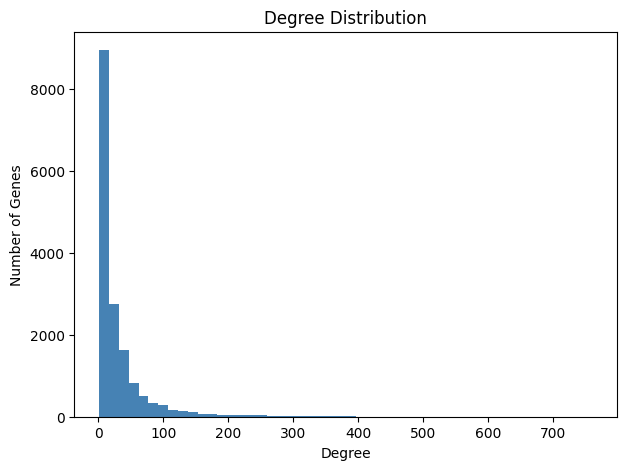

In [10]:
degrees = [d for n,d in G.degree()]

plt.figure(figsize=(7,5))

plt.hist(
    degrees,
    bins=50,
    color="steelblue"
)

plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Genes")

plt.show()

Degree Distribution (Log Scale)

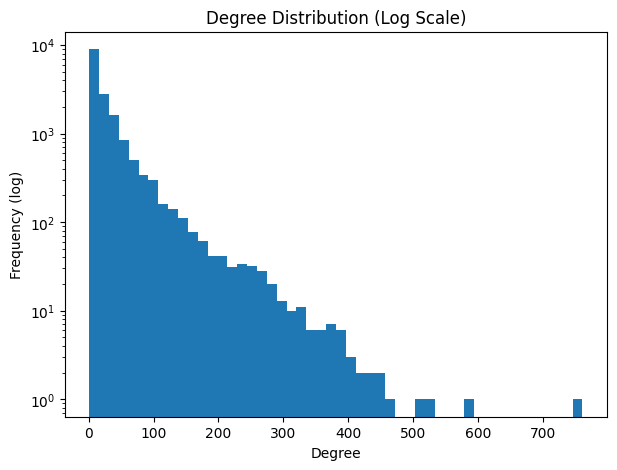

In [11]:
plt.figure(figsize=(7,5))

plt.hist(
    degrees,
    bins=50,
    log=True
)

plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency (log)")

plt.show()

Clustering Coefficient Distribution

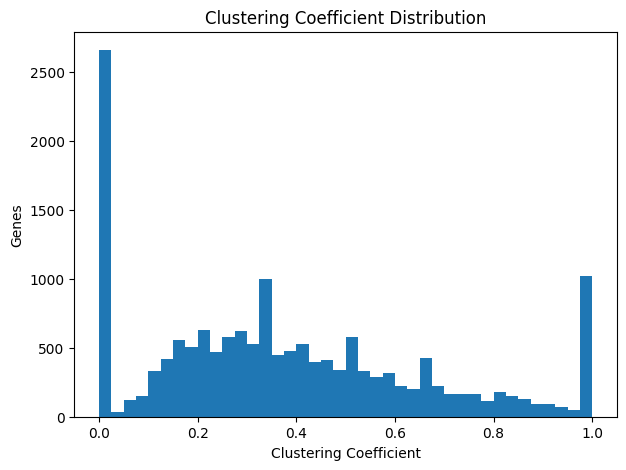

In [12]:
clustering = nx.clustering(G)

clustering_values = list(clustering.values())

plt.figure(figsize=(7,5))

plt.hist(
    clustering_values,
    bins=40
)

plt.title("Clustering Coefficient Distribution")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Genes")

plt.show()

Identify Hub Genes

In [13]:
degree_dict = dict(G.degree())

top_hubs = sorted(
    degree_dict.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top hub genes:")
print(top_hubs)

Top hub genes:
[('TP53', 761), ('RPS27A', 589), ('UBA52', 521), ('EGFR', 503), ('CTNNB1', 460), ('H4C6', 452), ('H3C13', 451), ('ACTB', 435), ('AKT1', 432), ('FAU', 423)]


Node2Vec Embedding Visualization

In [14]:
node2vec_cols = [c for c in df.columns if "node2vec" in c]

X = df[node2vec_cols]

UMAP Visualization

In [15]:
import umap

umap_model = umap.UMAP()

embedding = umap_model.fit_transform(X)

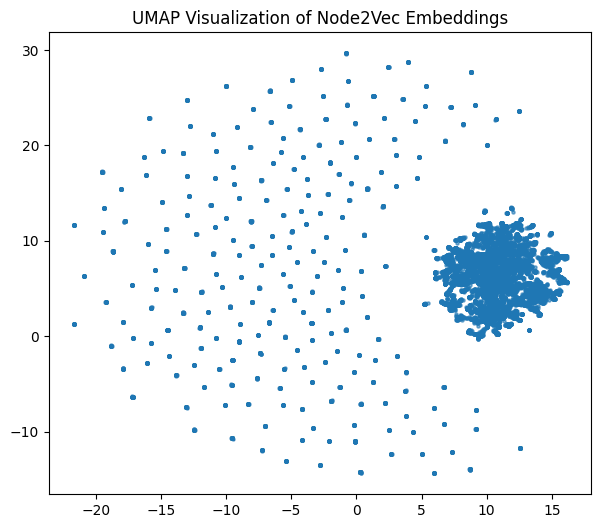

In [16]:
plt.figure(figsize=(7,6))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=5,
    alpha=0.6
)

plt.title("UMAP Visualization of Node2Vec Embeddings")

plt.show()

Label Clustering Visualization

Color points by label.

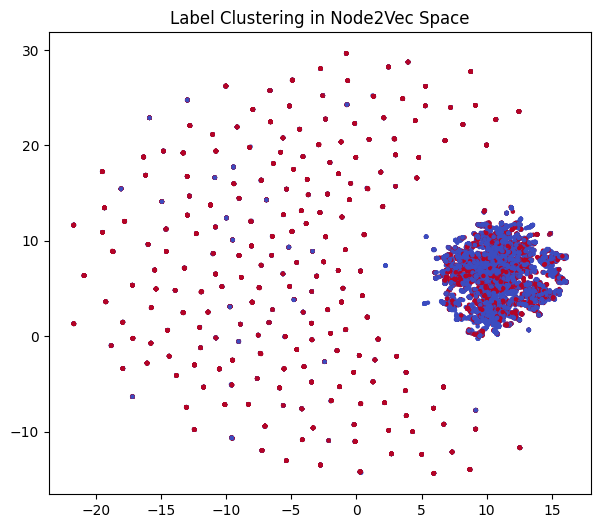

In [17]:
plt.figure(figsize=(7,6))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=df["label"],
    cmap="coolwarm",
    s=5
)

plt.title("Label Clustering in Node2Vec Space")

plt.show()

t-SNE Visualization (Optional)

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_embedding = tsne.fit_transform(X)

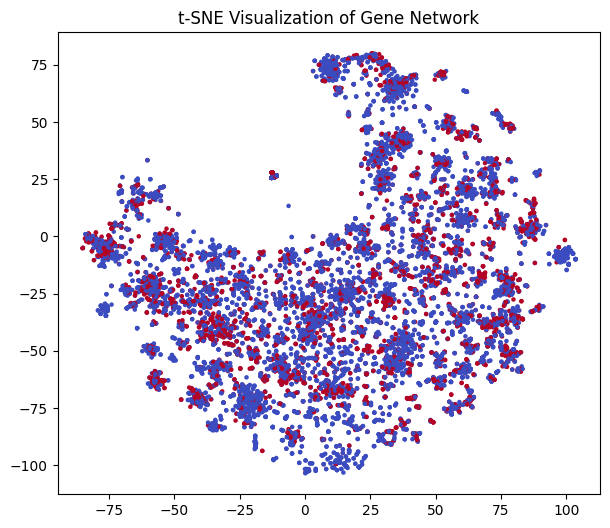

In [19]:
plt.figure(figsize=(7,6))

plt.scatter(
    tsne_embedding[:,0],
    tsne_embedding[:,1],
    c=df["label"],
    cmap="coolwarm",
    s=5
)

plt.title("t-SNE Visualization of Gene Network")

plt.show()

Neighbor Label Distribution

This shows disease signal propagation through the network.

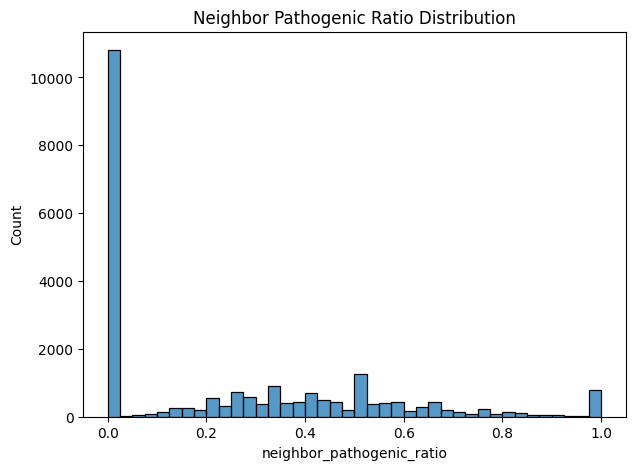

In [20]:
neighbor_ratio = df["neighbor_pathogenic_ratio"]

plt.figure(figsize=(7,5))

sns.histplot(neighbor_ratio, bins=40)

plt.title("Neighbor Pathogenic Ratio Distribution")

plt.show()

Prepare Data for GAT Attention Visualization

Create node index mapping.

In [21]:
gene_to_idx = {
    gene:i for i,gene in enumerate(df["GeneSymbol"])
}

In [22]:
edge_index = np.array([
    [gene_to_idx[s], gene_to_idx[t]]
    for s,t in zip(edges["gene1"], edges["gene2"])
    if s in gene_to_idx and t in gene_to_idx
]).T

print("Edge index shape:", edge_index.shape)

Edge index shape: (2, 367126)


Node Feature Matrix

In [23]:
features = df.drop(
    columns=["GeneSymbol","description","label"]
)

X = features.values

print("Node feature matrix shape:", X.shape)

Node feature matrix shape: (23050, 46)


Label Vector

In [24]:
y = df["label"].values

print("Label shape:", y.shape)

Label shape: (23050,)
